### **Lab Instructions**

#### **1. Import Required Libraries**
Start by importing the necessary Python libraries.

In [7]:
#load the dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#### **2. Load the Dataset**
Use a sample dataset or generate synthetic time series data.

In [12]:
#load the water usage dataset
df = pd.read_csv('Water_Usage_Data.csv', parse_dates=['Date'], index_col='Date')
# Display the first few rows of the dataset for residential gallons and industrial_gallons
print(df[['residential_gallons','industrial_gallons']].head())

            residential_gallons  industrial_gallons
Date                                               
2019-01-01          6896553.991         372027.0000
2019-01-02          7262534.651         538747.0000
2019-01-03          6214681.059         602900.0000
2019-01-04          6032113.704         613821.9999
2019-01-05          6678241.313         430945.0000


#### **3. Visualize the Dataset**
Plot the raw time series data

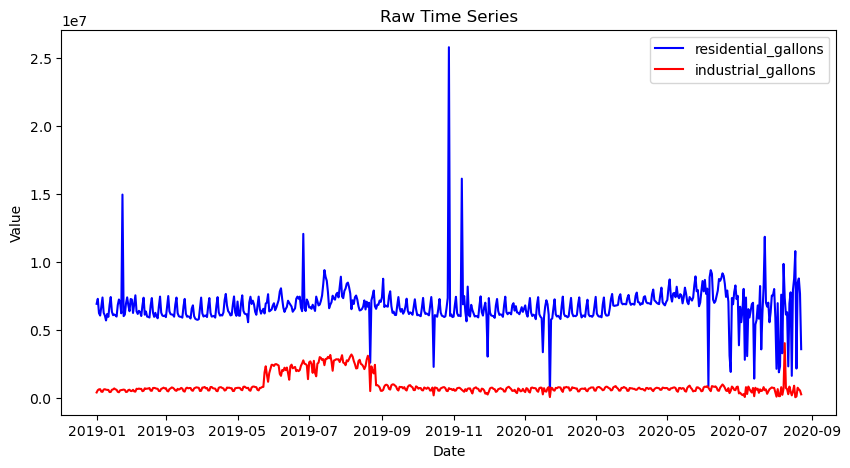

In [21]:
#plot the raw time series data for both variables, with residential gallons in blue and industrial gallons in red
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['residential_gallons'],'b-',df['industrial_gallons'],'r-')
plt.title('Raw Time Series')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend(['residential_gallons', 'industrial_gallons'])
plt.show()

#### **4. Transform the visualization**


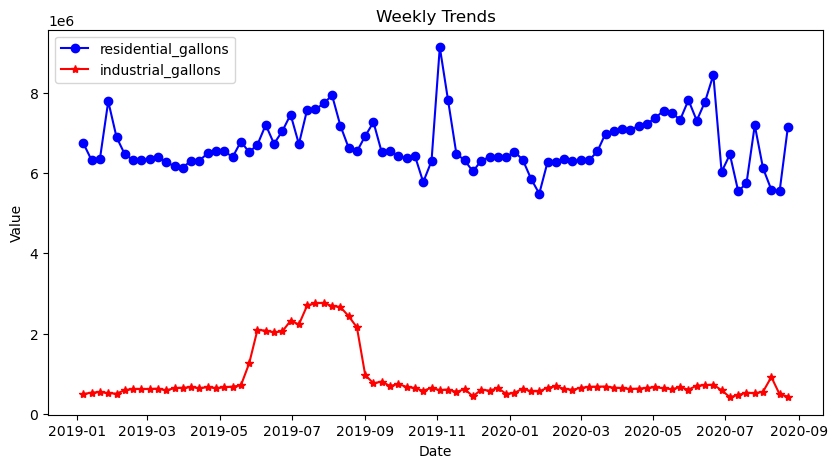

In [37]:
#Resample the data to observe weekly trends, and plot the resampled data
df_weekly = df[['residential_gallons','industrial_gallons']].resample('W').mean()
plt.figure(figsize=(10, 5))
plt.plot(df_monthly.index, df_weekly['residential_gallons'], marker='o', color='blue', label='Residential Gallons')
plt.plot(df_monthly.index, df_weekly['industrial_gallons'], marker='*', color='red', label='Industrial Gallons')
plt.title('Weekly Trends')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend(['residential_gallons', 'industrial_gallons'])
plt.show()

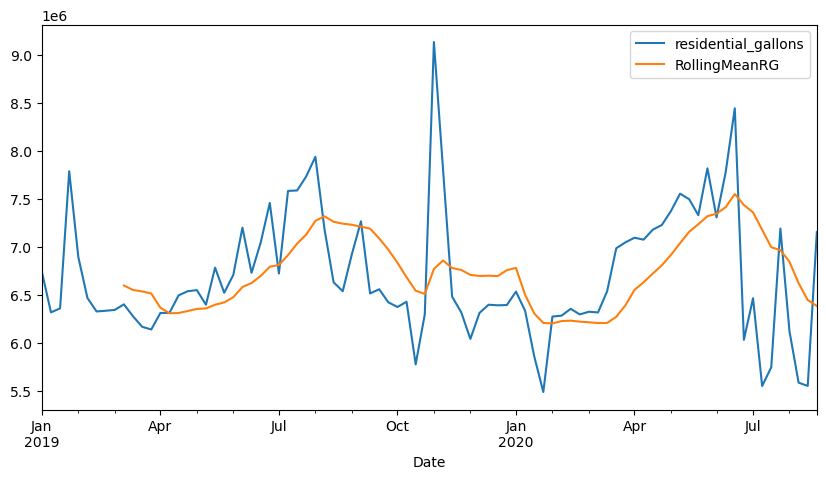

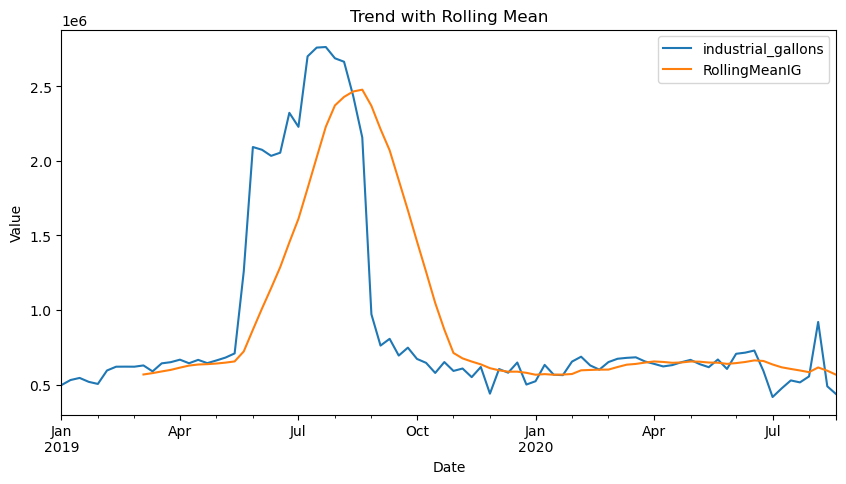

In [39]:
#Calculate and plot a rolling mean to highlight trends for the weekly data.
df_weekly['RollingMeanRG'] = df_weekly['residential_gallons'].rolling(window=10).mean()
df_weekly['RollingMeanIG'] = df_weekly['industrial_gallons'].rolling(window=10).mean()
df_weekly[['residential_gallons', 'RollingMeanRG']].plot(figsize=(10, 5))
df_weekly[['industrial_gallons', 'RollingMeanIG']].plot(figsize=(10, 5))
plt.title('Trend with Rolling Mean')
plt.xlabel('Date')
plt.ylabel('Value')
plt.show()

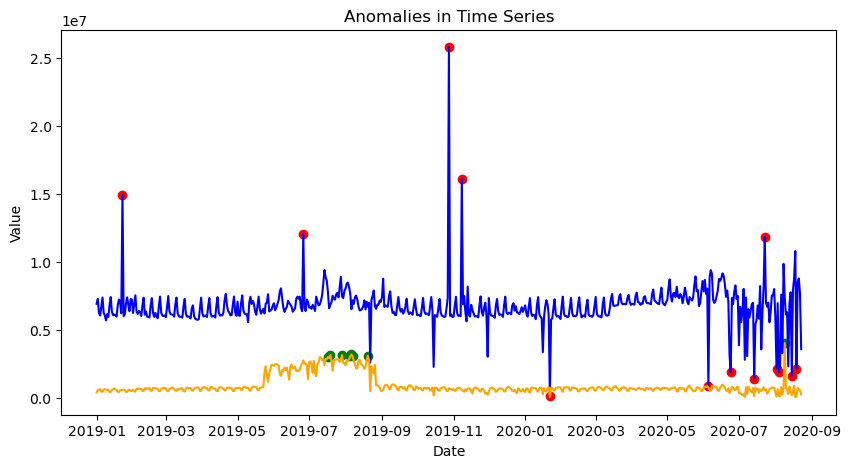

In [43]:
#Identify and visualize anomalies in the originial time series using Z-scores, for both variables. Plot residential gallons as a blue line with its anomalies highlighted as red dots
# In the same graph, plot the industrial gallon as an orange line with its anomalies highlightes as green dots

df['Z-Score_RG'] = (df['residential_gallons'] - df['residential_gallons'].mean()) / df['residential_gallons'].std()
anomaliesRG = df[df['Z-Score_RG'].abs() > 3]

df['Z-Score_IG'] = (df['industrial_gallons'] - df['industrial_gallons'].mean()) / df['industrial_gallons'].std()
anomaliesIG = df[df['Z-Score_IG'].abs() > 3]

plt.figure(figsize=(10, 5))
plt.plot(df.index, df['residential_gallons'], color='blue')
plt.scatter(anomaliesRG.index, anomaliesRG['residential_gallons'], color='red')

plt.plot(df.index, df['industrial_gallons'], color='orange')
plt.scatter(anomaliesIG.index, anomaliesIG['industrial_gallons'], color='green')

plt.title('Anomalies in Time Series')
plt.xlabel('Date')
plt.ylabel('Value')
plt.show()